In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import missingno as msno
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, cross_validate, cross_val_predict, RandomizedSearchCV
from sklearn.metrics import (
    roc_auc_score, classification_report, roc_curve, auc,
    precision_recall_curve, average_precision_score
)
from sklearn.calibration import CalibratedClassifierCV
from sklearn.base import clone
from xgboost import XGBClassifier
from scipy.stats import randint, uniform
import category_encoders as ce
from IPython.core.interactiveshell import InteractiveShell

sns.set_theme(style="whitegrid", palette="muted")
InteractiveShell.ast_node_interactivity = "all"
ROOT = "E://Dataset/Rain in Australia/"

E:\CYtravail\IA_App\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


转换类型Date RainToday RainTomorrow
协方差

In [27]:
df = pd.read_csv(ROOT + "weatherAUS.csv")
df.head()
df.dtypes.to_frame()
df.describe()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


,0
Date,str
Location,str
MinTemp,float64
MaxTemp,float64
Rainfall,float64
Evaporation,float64
Sunshine,float64
WindGustDir,str
WindGustSpeed,float64
WindDir9am,str


,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,143975.000000,144199.000000,142199.000000,82670.000000,75625.000000,135197.000000,143693.000000,142398.000000,142806.000000,140953.000000,130395.00000,130432.000000,89572.000000,86102.000000,143693.000000,141851.00000
mean,12.194034,23.221348,2.360918,5.468232,7.611178,40.035230,14.043426,18.662657,68.880831,51.539116,1017.64994,1015.255889,4.447461,4.509930,16.990631,21.68339
std,6.398495,7.119049,8.478060,4.193704,3.785483,13.607062,8.915375,8.809800,19.029164,20.795902,7.10653,7.037414,2.887159,2.720357,6.488753,6.93665
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.50000,977.100000,0.000000,0.000000,-7.200000,-5.40000
25%,7.600000,17.900000,0.000000,2.600000,4.800000,31.000000,7.000000,13.000000,57.000000,37.000000,1012.90000,1010.400000,1.000000,2.000000,12.300000,16.60000
50%,12.000000,22.600000,0.000000,4.800000,8.400000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.60000,1015.200000,5.000000,5.000000,16.700000,21.10000
75%,16.900000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.40000,1020.000000,7.000000,7.000000,21.600000,26.40000
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.00000,1039.600000,9.000000,9.000000,40.200000,46.70000


<Figure size 600x400 with 0 Axes>

<Axes: xlabel='RainTomorrow', ylabel='count'>

Text(0.5, 1.0, 'Distribution of Target Variable: RainTomorrow')

Text(0.5, 0, 'Will it rain tomorrow?')

Text(0, 0.5, 'Count')

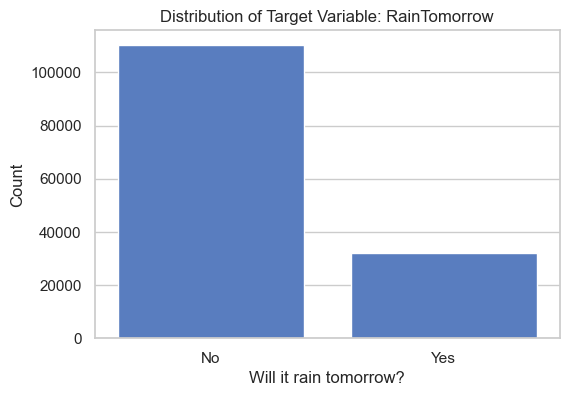

In [28]:
plt.figure(figsize=(6, 4))
# 使用 countplot 快速统计频数
sns.countplot(data=df, x='RainTomorrow')
plt.title('Distribution of Target Variable: RainTomorrow')
plt.xlabel('Will it rain tomorrow?')
plt.ylabel('Count')
plt.show()

Date              0.000000
Location          0.000000
MinTemp           1.020899
MaxTemp           0.866905
Rainfall          2.241853
Evaporation      43.166506
Sunshine         48.009762
WindGustDir       7.098859
WindGustSpeed     7.055548
WindDir9am        7.263853
WindDir3pm        2.906641
WindSpeed9am      1.214767
WindSpeed3pm      2.105046
Humidity9am       1.824557
Humidity3pm       3.098446
Pressure9am      10.356799
Pressure3pm      10.331363
Cloud9am         38.421559
Cloud3pm         40.807095
Temp9am           1.214767
Temp3pm           2.481094
RainToday         2.241853
RainTomorrow      2.245978
dtype: float64


<Axes: >

Text(0.5, 1.0, 'Missing Values Matrix')

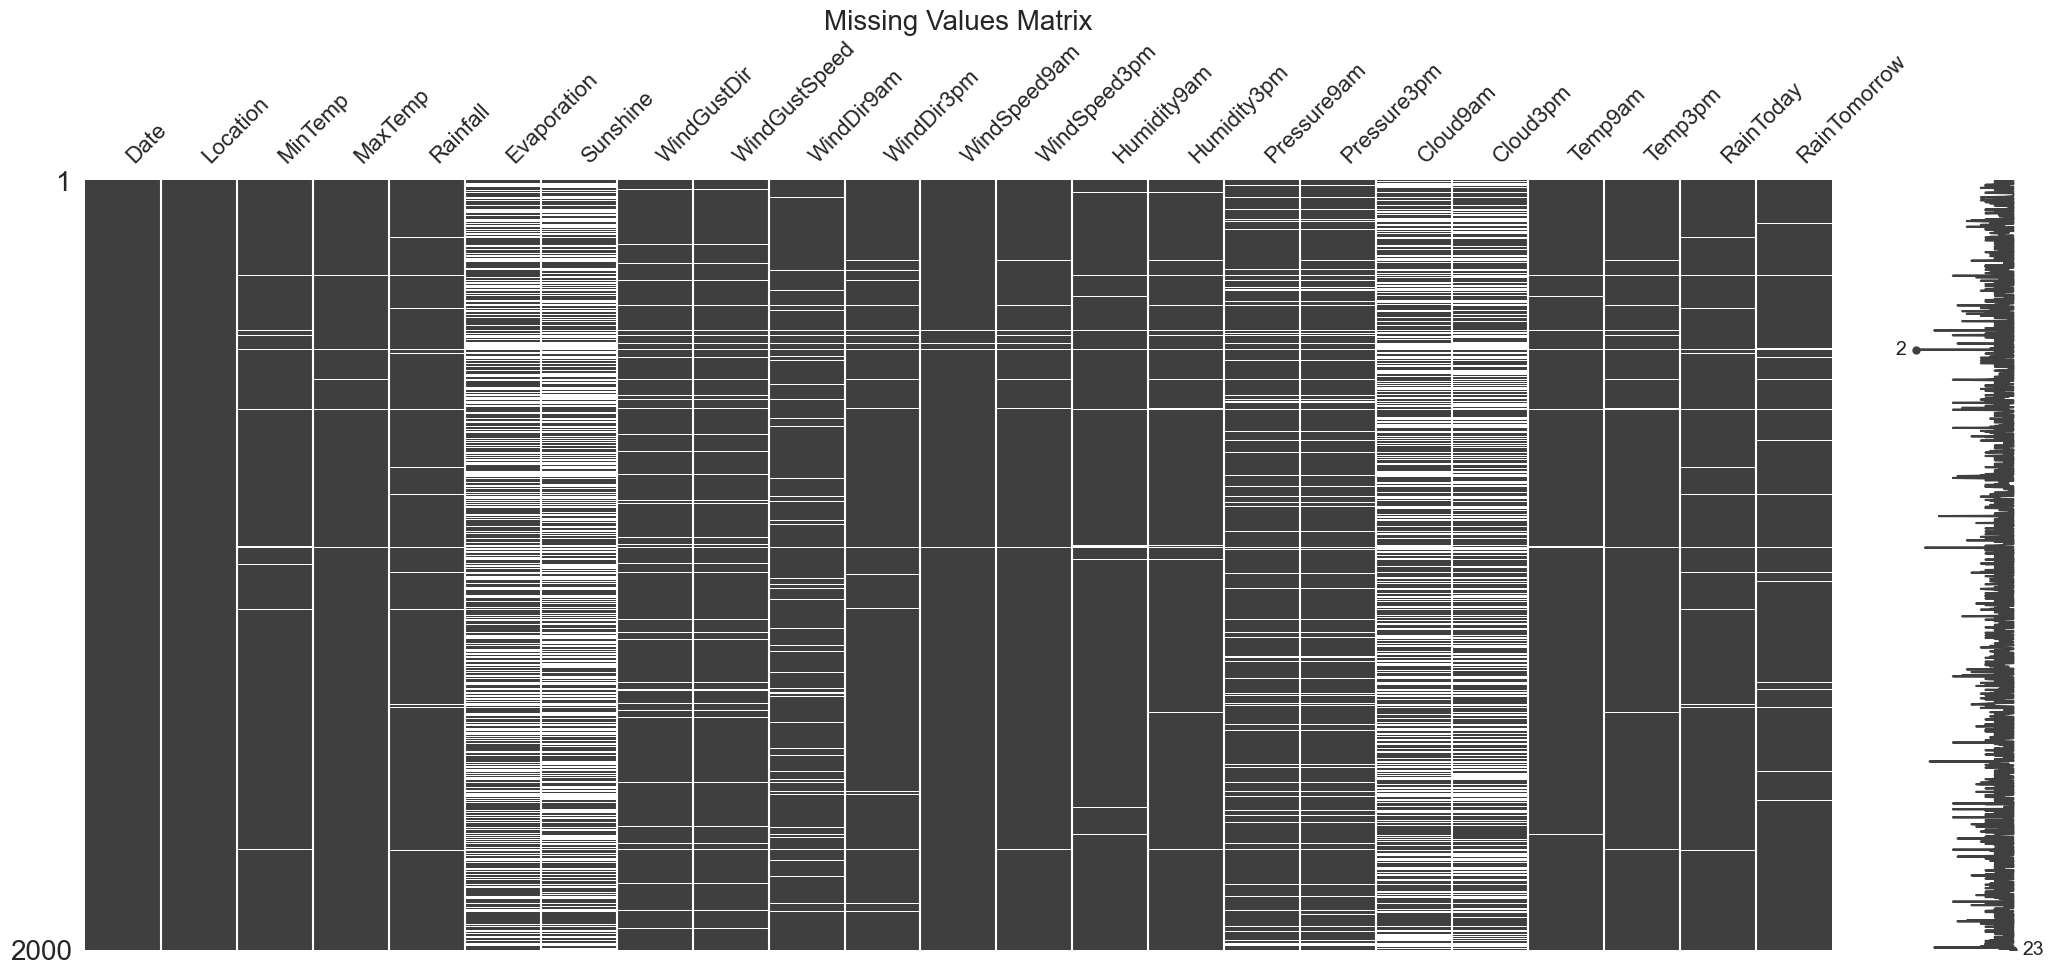

In [29]:
# 查看各列缺失值比例（打印文本）
print(df.isnull().mean() * 100)

# 使用 missingno 绘制缺失值矩阵图 (白色代表缺失)
# 这能帮你看出缺失值是不是成片出现的（比如某个气象站某天数据全无）
msno.matrix(df.sample(2000))  # 随机抽样 2000 行查看，避免数据量过大导致图表卡顿
plt.title('Missing Values Matrix', fontsize=20)
plt.show()

<Figure size 1600x1200 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Correlation Heatmap of Weather Variables')

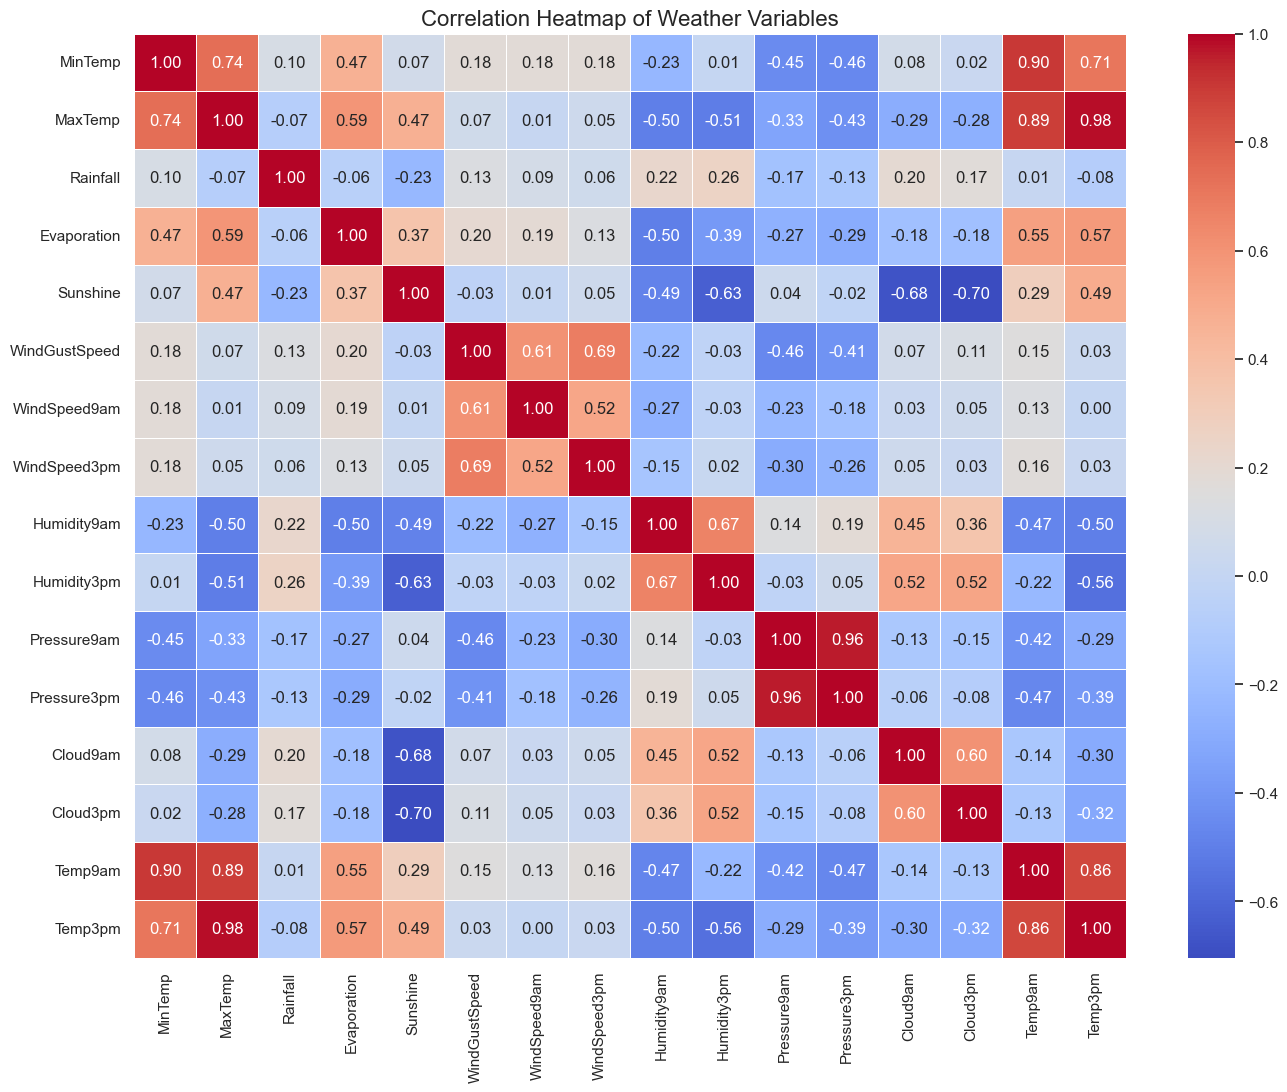

In [30]:
plt.figure(figsize=(16, 12))

# 提取所有数值型列并计算皮尔逊相关系数
numeric_cols = df.select_dtypes(include=['float64', 'int64'])
correlation_matrix = numeric_cols.corr()

# 绘制热力图
sns.heatmap(correlation_matrix,
            annot=True,  # 显示具体数值
            fmt=".2f",  # 保留两位小数
            cmap="coolwarm",  # 蓝红配色，冷暖分明
            linewidths=0.5)
plt.title('Correlation Heatmap of Weather Variables', fontsize=16)
plt.show()

<Figure size 800x600 with 0 Axes>

<Axes: xlabel='RainTomorrow', ylabel='Humidity3pm'>

Text(0.5, 1.0, 'Humidity at 3 PM vs Rain Tomorrow')

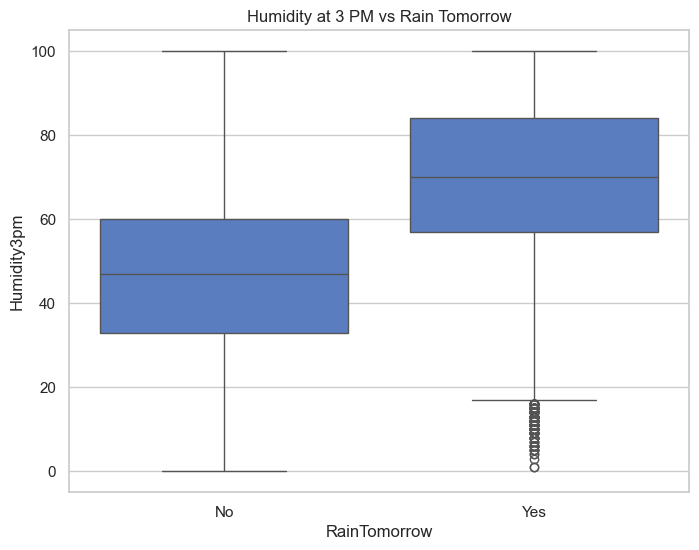

In [31]:
plt.figure(figsize=(8, 6))

# 画箱线图：横轴是目标变量，纵轴是特征变量
sns.boxplot(data=df, x='RainTomorrow', y='Humidity3pm')
plt.title('Humidity at 3 PM vs Rain Tomorrow')
plt.show()

In [32]:
missing_rates = df.isnull().mean()
low_missing_cols_auto = missing_rates[(missing_rates > 0) & (missing_rates < 0.05)].index.tolist()
print(f"自动检测到的低缺失率列: {low_missing_cols_auto}")

df = df.dropna(subset=low_missing_cols_auto)

自动检测到的低缺失率列: ['MinTemp', 'MaxTemp', 'Rainfall', 'WindDir3pm', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Temp9am', 'Temp3pm', 'RainToday', 'RainTomorrow']


In [33]:
df = df.drop(columns=['Sunshine', 'Evaporation', 'Cloud9am', 'Cloud3pm'])

df['RainToday'] = df['RainToday'].map({'No': 0, 'Yes': 1})
df['RainTomorrow'] = df['RainTomorrow'].map({'No': 0, 'Yes': 1})

# 2. 分组填充缺失值（以数值型变量为例，按 Location 填充均值）
# 相比直接 df.fillna(df.mean())，这种做法更加严谨和符合业务逻辑
numeric_cols_to_fill = ["WindGustSpeed", "Pressure9am", "Pressure3pm"]
for col in numeric_cols_to_fill:
    df[col] = df.groupby('Location')[col].transform(lambda x: x.fillna(x.median()))
    # 如果分组后仍有缺失（某地该变量全空），则用全局中位数兜底
    df[col] = df[col].fillna(df[col].median())

# 3. 时间特征衍生
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month
# 简单划分季节 (澳洲季节：12-2夏，3-5秋，6-8冬，9-11春)
df['Season'] = df['Month'].apply(
    lambda x: 1 if x in [12, 1, 2] else (2 if x in [3, 4, 5] else (3 if x in [6, 7, 8] else 4)))

# 4. 气象交互特征
df['TempDiff'] = df['MaxTemp'] - df['MinTemp']
df['HumidityDiff'] = df['Humidity3pm'] - df['Humidity9am']

# 关键：按时间排序，保证“过去 -> 未来”
df = df.sort_values('Date').reset_index(drop=True)

# 看看时间范围
print("最早日期:", df['Date'].min())
print("最晚日期:", df['Date'].max())

# 用最后 20% 的时间作为测试集
split_idx = int(len(df) * 0.8)

train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()

print("训练集时间范围:", train_df['Date'].min(), "->", train_df['Date'].max())
print("测试集时间范围:", test_df['Date'].min(), "->", test_df['Date'].max())
print("训练集大小:", train_df.shape)
print("测试集大小:", test_df.shape)

最早日期: 2007-11-01 00:00:00
最晚日期: 2017-06-25 00:00:00
训练集时间范围: 2007-11-01 00:00:00 -> 2015-10-20 00:00:00
测试集时间范围: 2015-10-20 00:00:00 -> 2017-06-25 00:00:00
训练集大小: (107672, 23)
测试集大小: (26918, 23)


In [35]:
feature_drop_cols = ['RainTomorrow', 'Date']

X_train = train_df.drop(columns=feature_drop_cols)
y_train = train_df['RainTomorrow']

X_test = test_df.drop(columns=feature_drop_cols)
y_test = test_df['RainTomorrow']

# 类别列：WOE 需要这些列
cat_cols = ['Location', 'WindDir9am', 'WindDir3pm', 'WindGustDir']

# 安全检查：这些列必须还在
print("类别列是否存在：", {col: col in X_train.columns for col in cat_cols})

# %%
# ==========================================
# 6. 定义 Pipeline
# ==========================================

def make_pipeline(model):
    return Pipeline([
        ('woe', ce.WOEEncoder(cols=cat_cols)),
        ('scaler', StandardScaler()),
        ('model', model)
    ])

scale_pos_weight_value = sum(y_train == 0) / sum(y_train == 1)

models = {
    "Logistic Regression": make_pipeline(
        LogisticRegression(
            class_weight='balanced',
            random_state=42,
            max_iter=1000
        )
    ),
    "Decision Tree": make_pipeline(
        DecisionTreeClassifier(
            class_weight='balanced',
            max_depth=6,
            random_state=42
        )
    ),
    "Random Forest": make_pipeline(
        RandomForestClassifier(
            class_weight='balanced',
            n_estimators=100,
            max_depth=10,
            random_state=42,
            n_jobs=-1
        )
    ),
    "XGBoost": make_pipeline(
        XGBClassifier(
            scale_pos_weight=scale_pos_weight_value,
            n_estimators=100,
            max_depth=6,
            learning_rate=0.1,
            random_state=42,
            eval_metric='logloss',
            n_jobs=-1
        )
    )
}

类别列是否存在： {'Location': True, 'WindDir9am': True, 'WindDir3pm': True, 'WindGustDir': True}


In [36]:
X_train.to_csv(ROOT + "X_train.csv", index=False)
X_test.to_csv(ROOT + "X_test.csv", index=False)
y_train.to_csv(ROOT + "y_train.csv", index=False)
y_test.to_csv(ROOT + "y_test.csv", index=False)

,Location,MinTemp,MaxTemp,Rainfall,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,...,Humidity3pm,Pressure9am,Pressure3pm,Temp9am,Temp3pm,RainToday,Month,Season,TempDiff,HumidityDiff
0,Canberra,8.0,24.3,0.0,NW,30.0,SW,NW,6.0,20.0,...,29.0,1019.7,1015.0,14.4,23.6,0,11,4,16.3,-39.0
1,Canberra,14.0,26.9,3.6,ENE,39.0,E,W,4.0,17.0,...,36.0,1012.4,1008.4,17.5,25.7,1,11,4,12.9,-44.0
2,Canberra,13.7,23.4,3.6,NW,85.0,N,NNE,6.0,6.0,...,69.0,1009.5,1007.2,15.4,20.2,1,11,4,9.7,-13.0
3,Canberra,13.3,15.5,39.8,NW,54.0,WNW,W,30.0,24.0,...,56.0,1005.5,1007.0,13.5,14.1,1,11,4,2.2,-6.0
4,Canberra,7.6,16.1,2.8,SSE,50.0,SSE,ESE,20.0,28.0,...,49.0,1018.3,1018.5,11.1,15.4,1,11,4,8.5,-19.0


<Figure size 1000x800 with 0 Axes>


========== TimeSeries 验证: Logistic Regression ==========


E:\CYtravail\IA_App\.venv\Lib\site-packages\sklearn\externals\_numpydoc\docscrape.py:420: UserWarning: Unknown section Example
  self[section] = content


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('woe', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,verbose,0
,cols,"['Location', 'WindDir9am', ...]"
,drop_invariant,False
,return_df,True
,handle_unknown,'value'
,handle_missing,'value'
,random_state,None


Fold 1: train=17947, val=17945


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('woe', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,verbose,0
,cols,"['Location', 'WindDir9am', ...]"
,drop_invariant,False
,return_df,True
,handle_unknown,'value'
,handle_missing,'value'
,random_state,None


Fold 2: train=35892, val=17945


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('woe', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,verbose,0
,cols,"['Location', 'WindDir9am', ...]"
,drop_invariant,False
,return_df,True
,handle_unknown,'value'
,handle_missing,'value'
,random_state,None


Fold 3: train=53837, val=17945


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('woe', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,verbose,0
,cols,"['Location', 'WindDir9am', ...]"
,drop_invariant,False
,return_df,True
,handle_unknown,'value'
,handle_missing,'value'
,random_state,None


Fold 4: train=71782, val=17945


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('woe', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,verbose,0
,cols,"['Location', 'WindDir9am', ...]"
,drop_invariant,False
,return_df,True
,handle_unknown,'value'
,handle_missing,'value'
,random_state,None


Fold 5: train=89727, val=17945
ROC-AUC : 0.8626 ± 0.0042
PR-AUC  : 0.6769 ± 0.0236
Precision: 0.5181
Recall   : 0.7545
F1-score : 0.6143
Accuracy : 0.7919

-> OOF 分类报告（基于时间验证）:
              precision    recall  f1-score   support

           0       0.92      0.80      0.86     69965
           1       0.52      0.76      0.62     19760

    accuracy                           0.79     89725
   macro avg       0.72      0.78      0.74     89725
weighted avg       0.83      0.79      0.80     89725




========== TimeSeries 验证: Decision Tree ==========


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('woe', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,verbose,0
,cols,"['Location', 'WindDir9am', ...]"
,drop_invariant,False
,return_df,True
,handle_unknown,'value'
,handle_missing,'value'
,random_state,None


Fold 1: train=17947, val=17945


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('woe', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,verbose,0
,cols,"['Location', 'WindDir9am', ...]"
,drop_invariant,False
,return_df,True
,handle_unknown,'value'
,handle_missing,'value'
,random_state,None


Fold 2: train=35892, val=17945


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('woe', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,verbose,0
,cols,"['Location', 'WindDir9am', ...]"
,drop_invariant,False
,return_df,True
,handle_unknown,'value'
,handle_missing,'value'
,random_state,None


Fold 3: train=53837, val=17945


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('woe', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,verbose,0
,cols,"['Location', 'WindDir9am', ...]"
,drop_invariant,False
,return_df,True
,handle_unknown,'value'
,handle_missing,'value'
,random_state,None


Fold 4: train=71782, val=17945


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('woe', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,verbose,0
,cols,"['Location', 'WindDir9am', ...]"
,drop_invariant,False
,return_df,True
,handle_unknown,'value'
,handle_missing,'value'
,random_state,None


Fold 5: train=89727, val=17945
ROC-AUC : 0.8430 ± 0.0067
PR-AUC  : 0.6446 ± 0.0175
Precision: 0.5040
Recall   : 0.7311
F1-score : 0.5954
Accuracy : 0.7820

-> OOF 分类报告（基于时间验证）:
              precision    recall  f1-score   support

           0       0.91      0.80      0.85     69965
           1       0.50      0.73      0.60     19760

    accuracy                           0.78     89725
   macro avg       0.71      0.76      0.72     89725
weighted avg       0.82      0.78      0.79     89725




========== TimeSeries 验证: Random Forest ==========


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('woe', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,verbose,0
,cols,"['Location', 'WindDir9am', ...]"
,drop_invariant,False
,return_df,True
,handle_unknown,'value'
,handle_missing,'value'
,random_state,None


Fold 1: train=17947, val=17945


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('woe', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,verbose,0
,cols,"['Location', 'WindDir9am', ...]"
,drop_invariant,False
,return_df,True
,handle_unknown,'value'
,handle_missing,'value'
,random_state,None


Fold 2: train=35892, val=17945


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('woe', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,verbose,0
,cols,"['Location', 'WindDir9am', ...]"
,drop_invariant,False
,return_df,True
,handle_unknown,'value'
,handle_missing,'value'
,random_state,None


Fold 3: train=53837, val=17945


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('woe', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,verbose,0
,cols,"['Location', 'WindDir9am', ...]"
,drop_invariant,False
,return_df,True
,handle_unknown,'value'
,handle_missing,'value'
,random_state,None


Fold 4: train=71782, val=17945


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('woe', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,verbose,0
,cols,"['Location', 'WindDir9am', ...]"
,drop_invariant,False
,return_df,True
,handle_unknown,'value'
,handle_missing,'value'
,random_state,None


Fold 5: train=89727, val=17945
ROC-AUC : 0.8678 ± 0.0079
PR-AUC  : 0.6975 ± 0.0186
Precision: 0.5879
Recall   : 0.6884
F1-score : 0.6334
Accuracy : 0.8252

-> OOF 分类报告（基于时间验证）:
              precision    recall  f1-score   support

           0       0.91      0.86      0.89     69965
           1       0.59      0.69      0.63     19760

    accuracy                           0.83     89725
   macro avg       0.75      0.78      0.76     89725
weighted avg       0.84      0.83      0.83     89725




========== TimeSeries 验证: XGBoost ==========


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('woe', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,verbose,0
,cols,"['Location', 'WindDir9am', ...]"
,drop_invariant,False
,return_df,True
,handle_unknown,'value'
,handle_missing,'value'
,random_state,None


Fold 1: train=17947, val=17945


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('woe', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,verbose,0
,cols,"['Location', 'WindDir9am', ...]"
,drop_invariant,False
,return_df,True
,handle_unknown,'value'
,handle_missing,'value'
,random_state,None


Fold 2: train=35892, val=17945


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('woe', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,verbose,0
,cols,"['Location', 'WindDir9am', ...]"
,drop_invariant,False
,return_df,True
,handle_unknown,'value'
,handle_missing,'value'
,random_state,None


Fold 3: train=53837, val=17945


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('woe', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,verbose,0
,cols,"['Location', 'WindDir9am', ...]"
,drop_invariant,False
,return_df,True
,handle_unknown,'value'
,handle_missing,'value'
,random_state,None


Fold 4: train=71782, val=17945


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('woe', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,verbose,0
,cols,"['Location', 'WindDir9am', ...]"
,drop_invariant,False
,return_df,True
,handle_unknown,'value'
,handle_missing,'value'
,random_state,None


Fold 5: train=89727, val=17945
ROC-AUC : 0.8796 ± 0.0066
PR-AUC  : 0.7245 ± 0.0128
Precision: 0.5638
Recall   : 0.7513
F1-score : 0.6435
Accuracy : 0.8172

-> OOF 分类报告（基于时间验证）:
              precision    recall  f1-score   support

           0       0.92      0.84      0.88     69965
           1       0.56      0.75      0.64     19760

    accuracy                           0.82     89725
   macro avg       0.74      0.79      0.76     89725
weighted avg       0.84      0.82      0.83     89725



Text(0.5, 1.0, 'TimeSeriesSplit ROC Curves on Training Set')

Text(0.5, 0, 'False Positive Rate')

Text(0, 0.5, 'True Positive Rate')

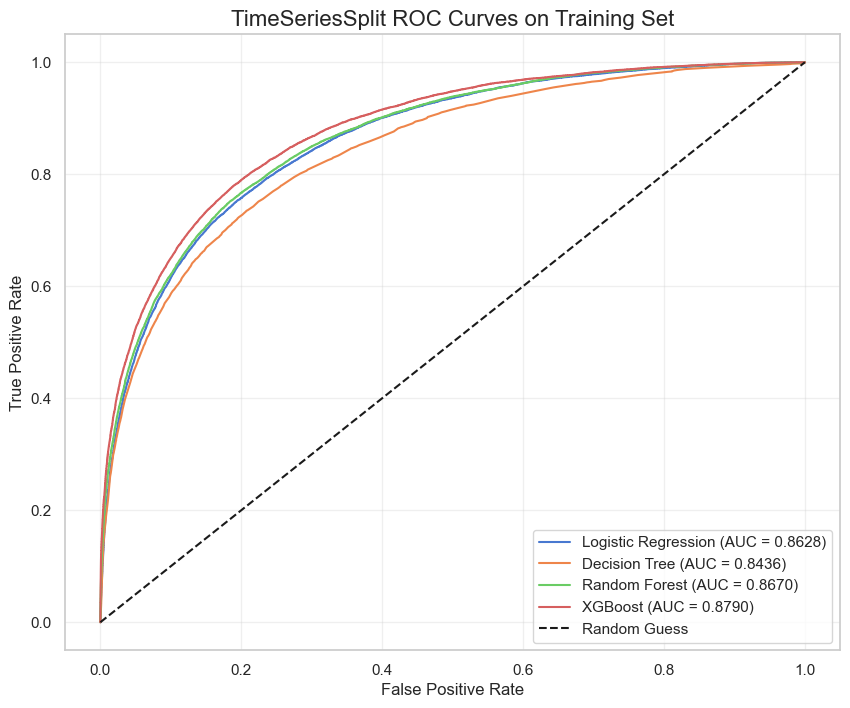


========== 时间序列交叉验证汇总 ==========
                 Model  CV ROC-AUC Mean  CV ROC-AUC Std  CV PR-AUC Mean  \
3              XGBoost         0.879581        0.006591        0.724472   
2        Random Forest         0.867768        0.007868        0.697509   
0  Logistic Regression         0.862563        0.004215        0.676925   
1        Decision Tree         0.842985        0.006702        0.644583   

   CV PR-AUC Std  CV Precision Mean  CV Recall Mean  CV F1 Mean  \
3       0.012765           0.563782        0.751297    0.643527   
2       0.018566           0.587858        0.688424    0.633392   
0       0.023634           0.518121        0.754528    0.614262   
1       0.017463           0.503990        0.731136    0.595380   

   CV Accuracy Mean  
3          0.817242  
2          0.825166  
0          0.791875  
1          0.782023  


In [38]:
tscv = TimeSeriesSplit(n_splits=5)

scoring = {
    'roc_auc': 'roc_auc',
    'average_precision': 'average_precision',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'accuracy': 'accuracy'
}

cv_summary = []

plt.figure(figsize=(10, 8))

for name, model in models.items():
    print(f"\n========== TimeSeries 验证: {name} ==========")

    # 交叉验证多指标
    cv_results = cross_validate(
        model,
        X_train,
        y_train,
        cv=tscv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False,
        error_score='raise'
    )

    # out-of-fold 概率预测
    # 对于 TimeSeriesSplit，cross_val_predict 有时不如手动写更稳
    oof_pred_proba = np.full(len(X_train), np.nan)

    for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train), start=1):
        X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

        model_fold = clone(model)
        model_fold.fit(X_tr, y_tr)
        oof_pred_proba[val_idx] = model_fold.predict_proba(X_val)[:, 1]

        print(f"Fold {fold}: train={len(tr_idx)}, val={len(val_idx)}")

    valid_mask = ~np.isnan(oof_pred_proba)
    y_train_valid = y_train.iloc[valid_mask]
    oof_pred_proba_valid = oof_pred_proba[valid_mask]
    oof_pred_valid = (oof_pred_proba_valid >= 0.5).astype(int)

    row = {
        'Model': name,
        'CV ROC-AUC Mean': cv_results['test_roc_auc'].mean(),
        'CV ROC-AUC Std': cv_results['test_roc_auc'].std(),
        'CV PR-AUC Mean': cv_results['test_average_precision'].mean(),
        'CV PR-AUC Std': cv_results['test_average_precision'].std(),
        'CV Precision Mean': cv_results['test_precision'].mean(),
        'CV Recall Mean': cv_results['test_recall'].mean(),
        'CV F1 Mean': cv_results['test_f1'].mean(),
        'CV Accuracy Mean': cv_results['test_accuracy'].mean()
    }
    cv_summary.append(row)

    print(f"ROC-AUC : {row['CV ROC-AUC Mean']:.4f} ± {row['CV ROC-AUC Std']:.4f}")
    print(f"PR-AUC  : {row['CV PR-AUC Mean']:.4f} ± {row['CV PR-AUC Std']:.4f}")
    print(f"Precision: {row['CV Precision Mean']:.4f}")
    print(f"Recall   : {row['CV Recall Mean']:.4f}")
    print(f"F1-score : {row['CV F1 Mean']:.4f}")
    print(f"Accuracy : {row['CV Accuracy Mean']:.4f}")

    print("\n-> OOF 分类报告（基于时间验证）:")
    print(classification_report(y_train_valid, oof_pred_valid))

    # 画基于 OOF 的 ROC 曲线
    fpr, tpr, _ = roc_curve(y_train_valid, oof_pred_proba_valid)
    auc_score = roc_auc_score(y_train_valid, oof_pred_proba_valid)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.4f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.title('TimeSeriesSplit ROC Curves on Training Set', fontsize=16)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

cv_results_df = pd.DataFrame(cv_summary).sort_values(by='CV ROC-AUC Mean', ascending=False)

print("\n========== 时间序列交叉验证汇总 ==========")
print(cv_results_df)

cv_results_df.to_csv(ROOT + "timeseries_cv_results_summary.csv", index=False)

In [39]:
best_model_name = cv_results_df.iloc[0]['Model']
print(f"\n最佳模型: {best_model_name}")

best_pipeline = clone(models[best_model_name])

# 用时间序列方式做校准更稳妥
calibrated_model = CalibratedClassifierCV(
    estimator=best_pipeline,
    method='sigmoid',
    cv=TimeSeriesSplit(n_splits=5)
)

calibrated_model.fit(X_train, y_train)


最佳模型: XGBoost


,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2","Pipeline(step...=None, ...))])"
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,verbose,0
,cols,"['Location', 'WindDir9am', ...]"
,drop_invariant,False
,return_df,True
,handle_unknown,'value'
,handle_missing,'value'


In [40]:
y_test_proba = calibrated_model.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_proba >= 0.5).astype(int)

test_roc_auc = roc_auc_score(y_test, y_test_proba)
test_pr_auc = average_precision_score(y_test, y_test_proba)

print("\n========== 最终未来测试集评估 ==========")
print(f"Best Model (Calibrated): {best_model_name}")
print(f"Test ROC-AUC: {test_roc_auc:.4f}")
print(f"Test PR-AUC : {test_pr_auc:.4f}")

print("\n-> 测试集分类报告:")
print(classification_report(y_test, y_test_pred))


========== 最终未来测试集评估 ==========
Best Model (Calibrated): XGBoost
Test ROC-AUC: 0.8779
Test PR-AUC : 0.7233

-> 测试集分类报告:
              precision    recall  f1-score   support

           0       0.89      0.93      0.91     21010
           1       0.70      0.58      0.63      5908

    accuracy                           0.85     26918
   macro avg       0.79      0.76      0.77     26918
weighted avg       0.85      0.85      0.85     26918



<Figure size 800x600 with 0 Axes>

Text(0.5, 1.0, 'Final ROC Curve on Future Test Set')

Text(0.5, 0, 'False Positive Rate')

Text(0, 0.5, 'True Positive Rate')

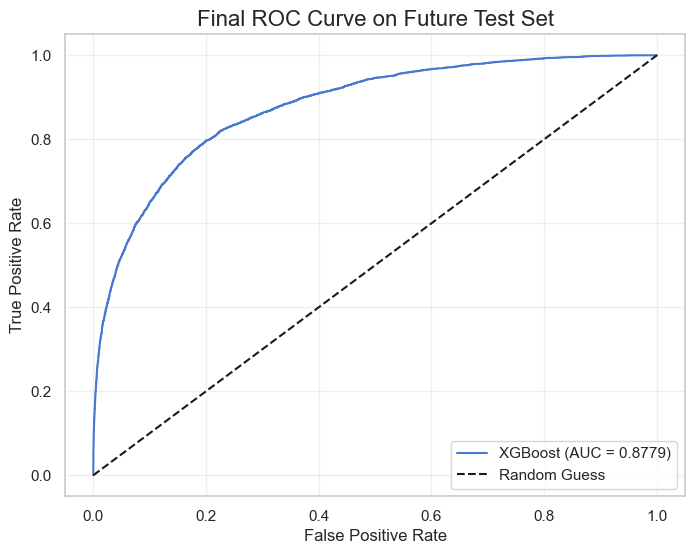

<Figure size 800x600 with 0 Axes>

Text(0.5, 1.0, 'Final Precision-Recall Curve on Future Test Set')

Text(0.5, 0, 'Recall')

Text(0, 0.5, 'Precision')

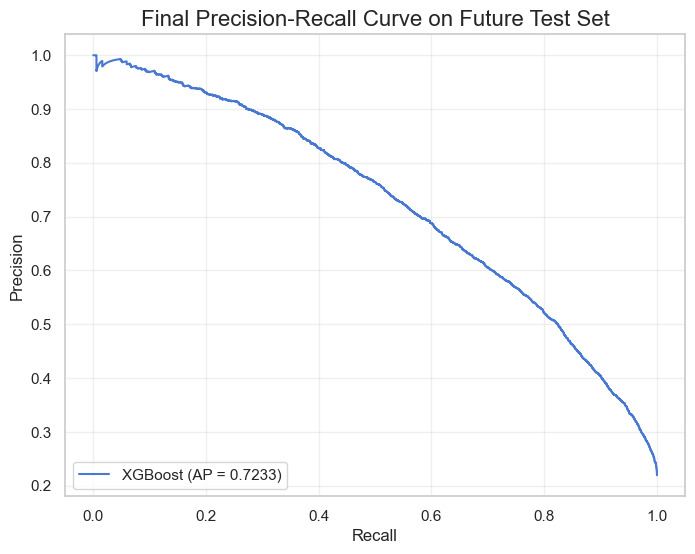

In [41]:
fpr, tpr, _ = roc_curve(y_test, y_test_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'{best_model_name} (AUC = {test_roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.title('Final ROC Curve on Future Test Set', fontsize=16)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

# PR
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_test_proba)

plt.figure(figsize=(8, 6))
plt.plot(recall_vals, precision_vals, label=f'{best_model_name} (AP = {test_pr_auc:.4f})')
plt.title('Final Precision-Recall Curve on Future Test Set', fontsize=16)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc='lower left')
plt.grid(alpha=0.3)
plt.show()


In [42]:
best_cv_row = cv_results_df.iloc[0]
gap = best_cv_row['CV ROC-AUC Mean'] - test_roc_auc

print("\n========== 泛化能力检查 ==========")
print(f"模型名称: {best_model_name}")
print(f"CV ROC-AUC  : {best_cv_row['CV ROC-AUC Mean']:.4f} ± {best_cv_row['CV ROC-AUC Std']:.4f}")
print(f"Test ROC-AUC: {test_roc_auc:.4f}")
print(f"AUC Gap (CV - Test): {gap:.4f}")

if gap > 0.03:
    print("提示：交叉验证显著高于未来测试集，可能存在过拟合或时间漂移。")
elif gap < -0.03:
    print("提示：未来测试集表现高于交叉验证，可能该时间段样本相对更容易。")
else:
    print("提示：交叉验证与未来测试集结果接近，泛化较稳定。")


========== 泛化能力检查 ==========
模型名称: XGBoost
CV ROC-AUC  : 0.8796 ± 0.0066
Test ROC-AUC: 0.8779
AUC Gap (CV - Test): 0.0017
提示：交叉验证与未来测试集结果接近，泛化较稳定。


In [45]:
rf_pipeline = make_pipeline(
    RandomForestClassifier(
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )
)

rf_param_dist = {
    'model__n_estimators': randint(100, 401),      # 100~400
    'model__max_depth': randint(4, 21),            # 4~20
    'model__min_samples_split': randint(2, 21),    # 2~20
    'model__min_samples_leaf': randint(1, 11),     # 1~10
    'model__max_features': ['sqrt', 'log2', None]
}

rf_random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_param_dist,
    n_iter=20,                 # 可先跑 20 次
    scoring='roc_auc',
    cv=tscv,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    error_score='raise'
)

rf_random_search.fit(X_train, y_train)

print("Random Forest 最优参数：")
print(rf_random_search.best_params_)
print(f"Random Forest 最优 CV ROC-AUC: {rf_random_search.best_score_:.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__max_depth': <scipy.stats....0022D85090CB0>, 'model__max_features': ['sqrt', 'log2', ...], 'model__min_samples_leaf': <scipy.stats....0022D85A3AF90>, 'model__min_samples_split': <scipy.stats....0022D85A393D0>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls

Random Forest 最优参数：
{'model__max_depth': 19, 'model__max_features': None, 'model__min_samples_leaf': 8, 'model__min_samples_split': 15, 'model__n_estimators': 314}
Random Forest 最优 CV ROC-AUC: 0.8752


In [46]:
xgb_pipeline = make_pipeline(
    XGBClassifier(
        scale_pos_weight=scale_pos_weight_value,
        random_state=42,
        eval_metric='logloss',
        n_jobs=-1
    )
)

xgb_param_dist = {
    'model__n_estimators': randint(100, 401),
    'model__max_depth': randint(3, 11),
    'model__learning_rate': uniform(0.03, 0.27),   # 0.03 ~ 0.30
    'model__subsample': uniform(0.6, 0.4),         # 0.6 ~ 1.0
    'model__colsample_bytree': uniform(0.6, 0.4),  # 0.6 ~ 1.0
    'model__min_child_weight': randint(1, 11),
    'model__gamma': uniform(0, 5)
}

xgb_random_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=xgb_param_dist,
    n_iter=20,
    scoring='roc_auc',
    cv=tscv,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    error_score='raise'
)

xgb_random_search.fit(X_train, y_train)

print("XGBoost 最优参数：")
print(xgb_random_search.best_params_)
print(f"XGBoost 最优 CV ROC-AUC: {xgb_random_search.best_score_:.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__colsample_bytree': <scipy.stats....0022D85A3A480>, 'model__gamma': <scipy.stats....0022D85A3A420>, 'model__learning_rate': <scipy.stats....0022D85A3AD80>, 'model__max_depth': <scipy.stats....0022D85A3A7E0>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls

XGBoost 最优参数：
{'model__colsample_bytree': np.float64(0.7710164073434198), 'model__gamma': np.float64(0.12709563372047594), 'model__learning_rate': np.float64(0.0591306852881922), 'model__max_depth': 9, 'model__min_child_weight': 7, 'model__n_estimators': 340, 'model__subsample': np.float64(0.7257423924305306)}
XGBoost 最优 CV ROC-AUC: 0.8825


In [48]:
best_search = (
    rf_random_search
    if rf_random_search.best_score_ >= xgb_random_search.best_score_
    else xgb_random_search
)

best_model_name = (
    'Random Forest'
    if rf_random_search.best_score_ >= xgb_random_search.best_score_
    else 'XGBoost'
)

best_model = best_search.best_estimator_

y_test_proba = best_model.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_proba >= 0.5).astype(int)

test_roc_auc = roc_auc_score(y_test, y_test_proba)
test_pr_auc = average_precision_score(y_test, y_test_proba)

print("\n========== 调参后未来测试集评估 ==========")
print(f"Best Model: {best_model_name}")
print(f"Best CV ROC-AUC: {best_search.best_score_:.4f}")
print(f"Test ROC-AUC: {test_roc_auc:.4f}")
print(f"Test PR-AUC : {test_pr_auc:.4f}")
print("\n分类报告：")
print(classification_report(y_test, y_test_pred))


========== 调参后未来测试集评估 ==========
Best Model: XGBoost
Best CV ROC-AUC: 0.8825
Test ROC-AUC: 0.8866
Test PR-AUC : 0.7400

分类报告：
              precision    recall  f1-score   support

           0       0.92      0.86      0.89     21010
           1       0.60      0.74      0.66      5908

    accuracy                           0.83     26918
   macro avg       0.76      0.80      0.77     26918
weighted avg       0.85      0.83      0.84     26918



In [49]:
calibrated_model = CalibratedClassifierCV(
    estimator=best_model,
    method='sigmoid',
    cv=TimeSeriesSplit(n_splits=5)
)

calibrated_model.fit(X_train, y_train)

y_test_proba_cal = calibrated_model.predict_proba(X_test)[:, 1]
y_test_pred_cal = (y_test_proba_cal >= 0.5).astype(int)

print("\n========== 校准后未来测试集评估 ==========")
print(f"Calibrated Test ROC-AUC: {roc_auc_score(y_test, y_test_proba_cal):.4f}")
print(f"Calibrated Test PR-AUC : {average_precision_score(y_test, y_test_proba_cal):.4f}")
print(classification_report(y_test, y_test_pred_cal))

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2","Pipeline(step...=None, ...))])"
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,verbose,0
,cols,"['Location', 'WindDir9am', ...]"
,drop_invariant,False
,return_df,True
,handle_unknown,'value'
,handle_missing,'value'



========== 校准后未来测试集评估 ==========
Calibrated Test ROC-AUC: 0.8849
Calibrated Test PR-AUC : 0.7356
              precision    recall  f1-score   support

           0       0.89      0.93      0.91     21010
           1       0.71      0.59      0.65      5908

    accuracy                           0.86     26918
   macro avg       0.80      0.76      0.78     26918
weighted avg       0.85      0.86      0.85     26918



In [51]:
# 取出 pipeline 里的 xgboost 模型
xgb_model = best_model.named_steps['model']

# 特征名
feature_names = X_train.columns

# importance
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importance_df.head(15))

          Feature  Importance
11    Humidity3pm    0.260843
5   WindGustSpeed    0.072270
16      RainToday    0.065364
13    Pressure3pm    0.049088
3        Rainfall    0.047581
7      WindDir3pm    0.041144
0        Location    0.036362
19       TempDiff    0.035429
12    Pressure9am    0.033882
18         Season    0.032837
10    Humidity9am    0.032168
4     WindGustDir    0.030430
20   HumidityDiff    0.030202
9    WindSpeed3pm    0.030117
6      WindDir9am    0.029906


<Figure size 1000x800 with 0 Axes>

<BarContainer object of 15 artists>

Text(0.5, 1.0, 'Top 15 Feature Importances (XGBoost)')

Text(0.5, 0, 'Importance Score')

Text(0, 0.5, 'Feature')

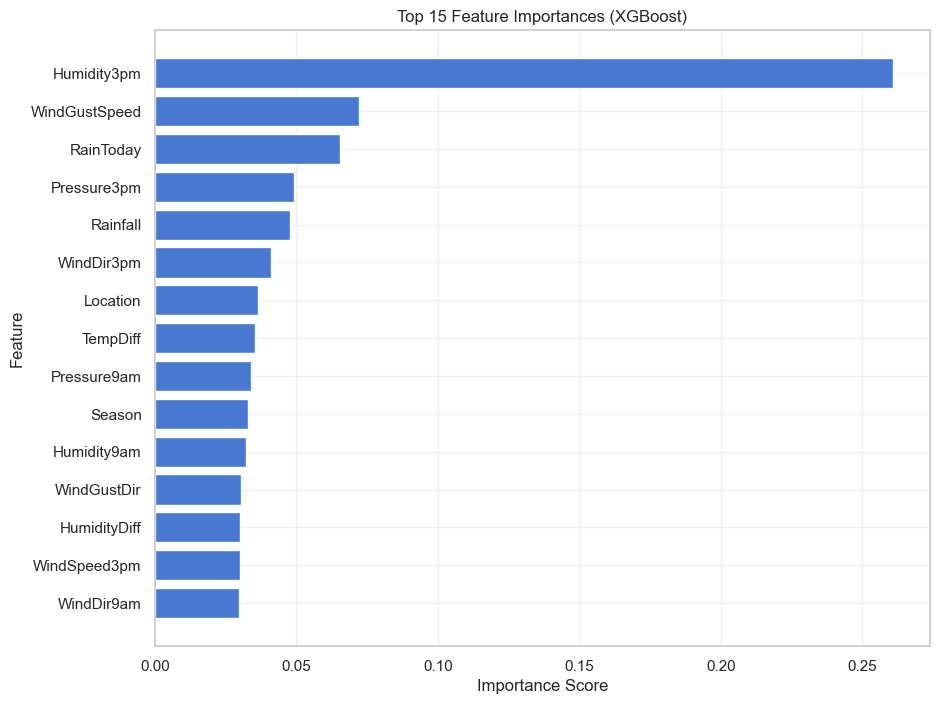

In [52]:
plt.figure(figsize=(10, 8))
top_k = 15
plot_df = importance_df.head(top_k).sort_values(by='Importance')

plt.barh(plot_df['Feature'], plot_df['Importance'])
plt.title('Top 15 Feature Importances (XGBoost)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.grid(alpha=0.3)
plt.show()

In [53]:
# 取出各步骤
woe_step = best_model.named_steps['woe']
scaler_step = best_model.named_steps['scaler']
xgb_model = best_model.named_steps['model']

# 转换训练集和测试集
X_train_woe = woe_step.transform(X_train)
X_test_woe = woe_step.transform(X_test)

X_train_scaled = pd.DataFrame(
    scaler_step.transform(X_train_woe),
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler_step.transform(X_test_woe),
    columns=X_test.columns,
    index=X_test.index
)

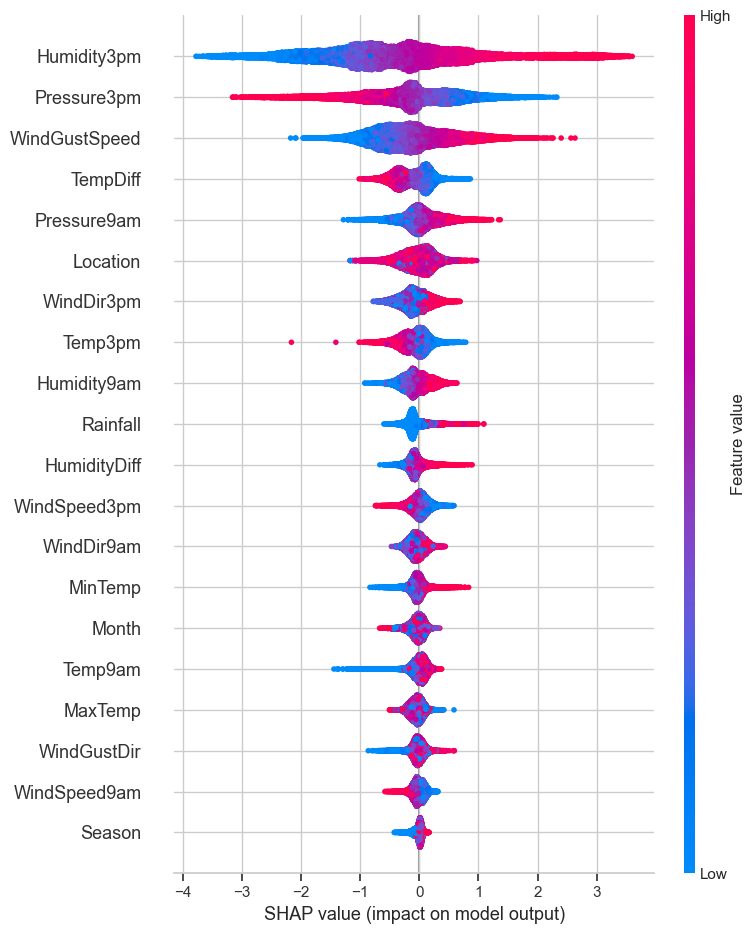

In [54]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_scaled)
shap.summary_plot(shap_values, X_test_scaled, feature_names=X_test_scaled.columns)

In [55]:
y_test_proba = best_model.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_proba >= 0.5).astype(int)

In [56]:
error_df = X_test.copy()
error_df['y_true'] = y_test.values
error_df['y_pred'] = y_test_pred
error_df['y_proba'] = y_test_proba

def label_case(row):
    if row['y_true'] == 1 and row['y_pred'] == 1:
        return 'TP'
    elif row['y_true'] == 0 and row['y_pred'] == 0:
        return 'TN'
    elif row['y_true'] == 0 and row['y_pred'] == 1:
        return 'FP'
    else:
        return 'FN'

error_df['case_type'] = error_df.apply(label_case, axis=1)

print(error_df['case_type'].value_counts())

case_type
TN    18039
TP     4370
FP     2971
FN     1538
Name: count, dtype: int64


In [58]:
fp_df = error_df[error_df['case_type'] == 'FP']
fn_df = error_df[error_df['case_type'] == 'FN']
tp_df = error_df[error_df['case_type'] == 'TP']
tn_df = error_df[error_df['case_type'] == 'TN']

compare_cols = ['Humidity3pm', 'Pressure3pm', 'TempDiff', 'HumidityDiff', 'RainToday']

comparison = pd.DataFrame({
    'FP_mean': fp_df[compare_cols].mean(),
    'FN_mean': fn_df[compare_cols].mean(),
    'TP_mean': tp_df[compare_cols].mean(),
    'TN_mean': tn_df[compare_cols].mean()
})

print(comparison)

                  FP_mean      FN_mean      TP_mean      TN_mean
Humidity3pm     65.226860    50.921977    74.758810    43.134930
Pressure3pm   1012.667317  1013.799090  1011.316384  1016.093464
TempDiff         8.292797    11.076073     7.060183    12.727091
HumidityDiff   -12.258499   -16.983745    -5.993135   -21.082765
RainToday        0.442612     0.184005     0.539588     0.111758


In [59]:
fp_location = fp_df['Location'].value_counts().head(10)
fn_location = fn_df['Location'].value_counts().head(10)

print("Top FP Locations:")
print(fp_location)

print("\nTop FN Locations:")
print(fn_location)

Top FP Locations:
Location
Cairns           121
GoldCoast        119
NorahHead        105
NorfolkIsland    105
CoffsHarbour     100
SydneyAirport     98
Sale              91
Darwin            88
Portland          84
Hobart            84
Name: count, dtype: int64

Top FN Locations:
Location
Sydney              50
Williamtown         50
SalmonGums          47
Tuggeranong         47
Launceston          47
Canberra            46
Brisbane            45
Watsonia            44
Portland            43
MelbourneAirport    41
Name: count, dtype: int64
